In [ ]:
!pip install --upgrade git+https://github.com/ColibrITD-SAS/landscape_tools@dev
#!pip install landscape-tools

# Imports

In [ ]:
from landscape_tools import barren_plateaus as bp
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import Statevector
from qiskit.quantum_info import Pauli

# Example of a problem

## Probability distribution

In [13]:
def get_prob_distribution(params, ansatz, theta_params):

    param_dict = dict(zip(theta_params, params))                                
    # param_dict = {
    #     θ0: 0.5,
    #     θ1: 1.2
    # }

    bound_circuit = ansatz.assign_parameters(param_dict, inplace=False)

    state = Statevector.from_instruction(bound_circuit)
    probs = state.probabilities()

    return np.asarray(probs, dtype=float)

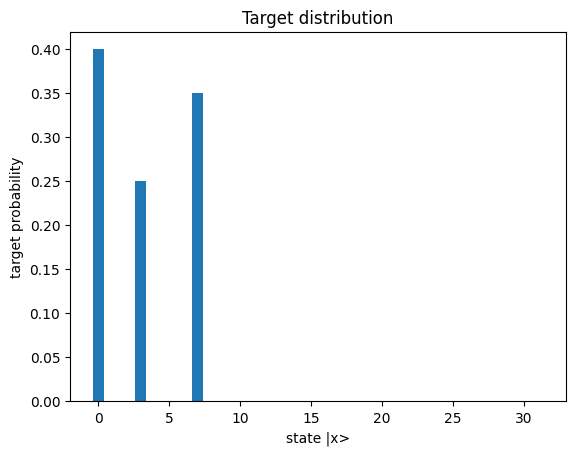

In [14]:
n_qubits = 5
dim = 2 ** n_qubits

p_target = np.zeros(dim)

# index 0 -> |000>, index 1 -> |001>, ..., index 7 -> |111>
p_target[0] = 0.40  # |000>
p_target[3] = 0.25  # |011>
p_target[7] = 0.35  # |111>

p_target = p_target / p_target.sum()    # normalize to ensure probabilities sum to 1

plt.bar(range(dim), p_target)
plt.xlabel("state |x>")
plt.ylabel("target probability")
plt.title("Target distribution")
plt.show()

## Quantum circuit

In [15]:
def build_hea_ansatz(n_qubits, n_layers, Ansatz):
    """
    Hardware Efficient Ansatz :
    - RY + RZ on each qubit
    - CNOT chain
    """
    qc = QuantumCircuit(n_qubits)

    n_params = 2 * n_qubits * n_layers
    theta = ParameterVector("θ", n_params)

    k = 0
    for _ in range(n_layers):
        for q in range(n_qubits):
            qc.ry(theta[k], q)
            k += 1
            qc.rz(theta[k], q)
            k += 1

        for q in range(n_qubits - 1):
            qc.cx(q, q + 1)

    qc.metadata = {"parameters": theta, "ansatz_name": Ansatz,}

    return qc

In [16]:
def generate_params_hea(n_qubits, n_layers):
    """
    Generate random parameters for HEA ansatz (uniform distribution).
    """

    n_params = 2 * n_qubits * n_layers
    params = np.random.uniform(0, 2 * np.pi, n_params)

    return params

Number of parameters: 20


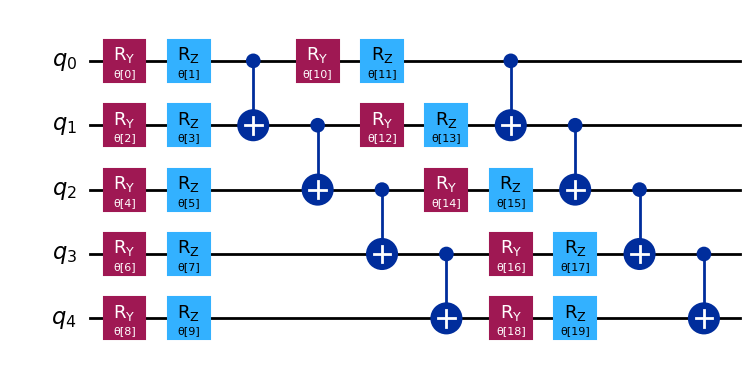

In [17]:
n_layers = 2

ansatz = build_hea_ansatz(n_qubits, n_layers, "HEA_test")
theta_params = ansatz.metadata["parameters"]

n_params = len(theta_params)

print("Number of parameters:", n_params)
ansatz.draw("mpl")

## Loss function

In [18]:
def mse_loss(params, ansatz, theta_params, p_target):
    p_model = get_prob_distribution(params, ansatz, theta_params)
    return np.sum((p_model - p_target) ** 2)

In [19]:
def circuit_mse_loss_builder(
    context,
    target="uniform",
):
    from qiskit.quantum_info import Statevector

    circuit = context["circuits"]
    n_qubits = context["n_qubits"]

    if circuit.metadata is not None and "parameters" in circuit.metadata:
        parameters = circuit.metadata["parameters"]
    else:
        parameters = list(circuit.parameters)

    dim = 2 ** n_qubits

    if target == "zero":
        p_target = np.zeros(dim)
        p_target[0] = 1.0

    elif target == "uniform":
        p_target = np.ones(dim) / dim

    else:
        raise ValueError("target must be either 'zero' or 'uniform'.")

    def loss(theta):
        theta = np.asarray(theta, dtype=float)

        bound_circuit = circuit.assign_parameters(
            dict(zip(parameters, theta)),
            inplace=False,
        )

        probs = Statevector.from_instruction(bound_circuit).probabilities()

        value = np.sum((probs - p_target) ** 2)

        return float(value)

    return loss

# Barren Plateaus Analysis

In [ ]:
experiment1 = bp.ExperimentConfig(
    analysis_type="layerwise_qubits_padding",
    N_qubits=[2,4,6,8],
    N_layers=[2,4,8],
    ansatz_name="HEA_test",
    initial_Pauli_string=None, #Pauli('IZ'),
    padding_types=None #["I","linear_half"],
)

experiment2 = bp.ExperimentConfig(
    analysis_type="joint_scaling_padding",
    N_qubits=[2,4,6,8],
    N_layers=[2,4,8],
    ansatz_name="HEA_test",
    initial_Pauli_string=None,   #Pauli('IZ'),
    padding_types=None  #["log"],
)

experiment3 = bp.ExperimentConfig(
    analysis_type="layerwise_qubits",
    N_qubits=[2,4,6,8],
    N_layers=[2,4,8],
    ansatz_name="HEA_test",
    observables_list=None   #[Pauli('IZ'),Pauli('IZIZ'),Pauli('IZZIZZ'),Pauli('IZZZZZZZ')]
)

sampling = bp.SamplingConfig(
    bootstrap_B=500,
    rel_err_target=0.05,
    N_max=20000,
)

execution = bp.ExecutionConfig(
    verbose=True,
    n_jobs=8
)

--------------------
Number of qubits: 2
Number of layers: 2


[Adaptive sampling] N = 900 | relative error = 5.58%
[Adaptive sampling] Adding 444 samples (N: 900 -> 1344)


[Adaptive sampling] N = 1344 | relative error = 4.71%
[Adaptive sampling] Target reached with N_samples = 1344 (relative error target reached)
var = 0.019981342426901118
--------------------
Number of qubits: 4
Number of layers: 2


[Adaptive sampling] N = 900 | relative error = 8.06%
[Adaptive sampling] Adding 1904 samples (N: 900 -> 2804)


[Adaptive sampling] N = 2804 | relative error = 5.04%
[Adaptive sampling] Adding 612 samples (N: 2804 -> 3416)


...

[Adaptive sampling] N = 1493 | relative error = 4.65%
[Adaptive sampling] Target reached with N_samples = 1493 (relative error target reached)
var = 1.62798578110565e-05
--------------------
Number of qubits: 8
Number of layers: 8


[Adaptive sampling] N = 900 | relative error = 7.71%
[Adaptive sampling] Adding 1666 samples (N: 900 -> 2566)


[Adaptive sampling] N = 2566 | relative error = 5.49%
[Adaptive sampling] Adding 1153 samples (N: 2566 -> 3719)


[Adaptive sampling] N = 3719 | relative error = 5.64%
[Adaptive sampling] Adding 1964 samples (N: 3719 -> 5683)


[Adaptive sampling] N = 5683 | relative error = 3.87%
[Adaptive sampling] Target reached with N_samples = 5683 (relative error target reached)
var = 4.91280710279413e-07


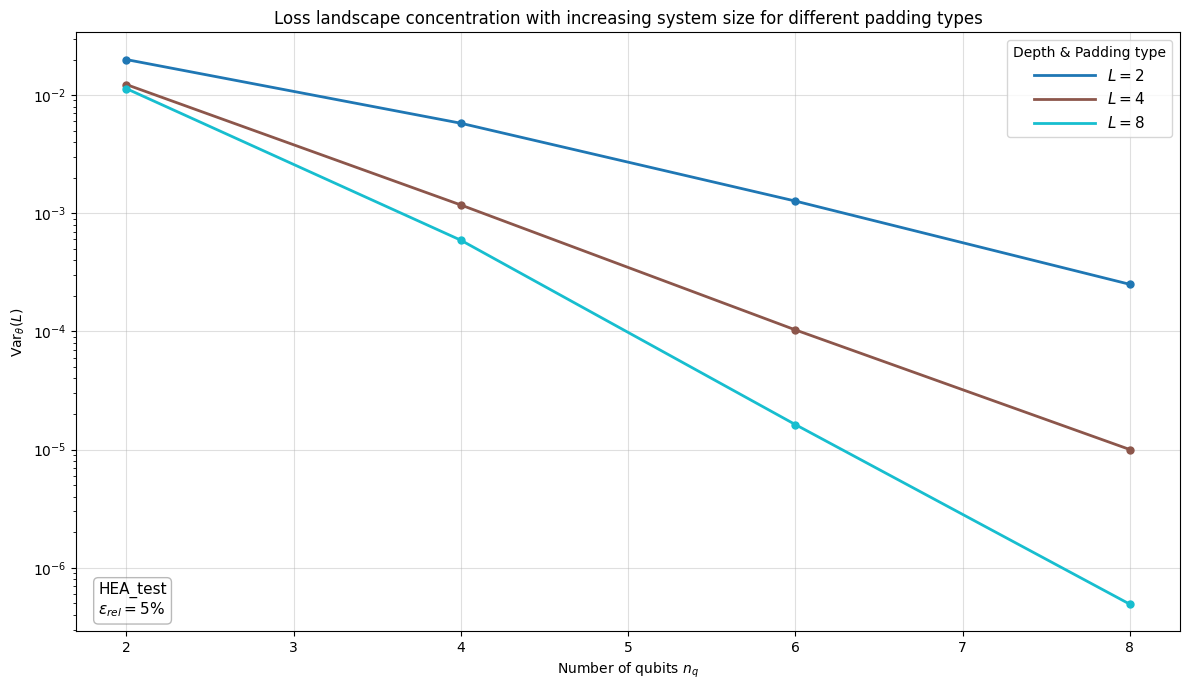

In [21]:
result1 = bp.barren_plateaus_analysis(
    experiment=experiment1,
    cost_function_builder=circuit_mse_loss_builder,
    generate_params=generate_params_hea,
    generate_circuits=build_hea_ansatz,
    sampling=sampling,
    execution=execution,
)

--------------------
Number of qubits: 2
Number of layers: 2
Padding type: log
Pauli string: IZ


[Adaptive sampling] N = 900 | relative error = 5.94%
[Adaptive sampling] Adding 624 samples (N: 900 -> 1524)


[Adaptive sampling] N = 1524 | relative error = 4.46%
[Adaptive sampling] Target reached with N_samples = 1524 (relative error target reached)
var = 0.019593901279035743
--------------------
Number of qubits: 4
Number of layers: 4
Padding type: log
Pauli string: IZIZ


[Adaptive sampling] N = 900 | relative error = 8.61%
[Adaptive sampling] Adding 2304 samples (N: 900 -> 3204)


[Adaptive sampling] N = 3204 | relative error = 6.08%
[Adaptive sampling] Adding 2481 samples (N: 3204 -> 5685)


...

[Adaptive sampling] N = 900 | relative error = 6.79%
[Adaptive sampling] Adding 1094 samples (N: 900 -> 1994)


[Adaptive sampling] N = 1994 | relative error = 4.59%
[Adaptive sampling] Target reached with N_samples = 1994 (relative error target reached)
var = 1.549042566919089e-05
--------------------
Number of qubits: 8
Number of layers: 8
Padding type: log
Pauli string: IIIIZZIZ


[Adaptive sampling] N = 900 | relative error = 6.10%
[Adaptive sampling] Adding 706 samples (N: 900 -> 1606)


[Adaptive sampling] N = 1606 | relative error = 5.36%
[Adaptive sampling] Adding 606 samples (N: 1606 -> 2212)


[Adaptive sampling] N = 2212 | relative error = 4.57%
[Adaptive sampling] Target reached with N_samples = 2212 (relative error target reached)
var = 4.7058411699374697e-07


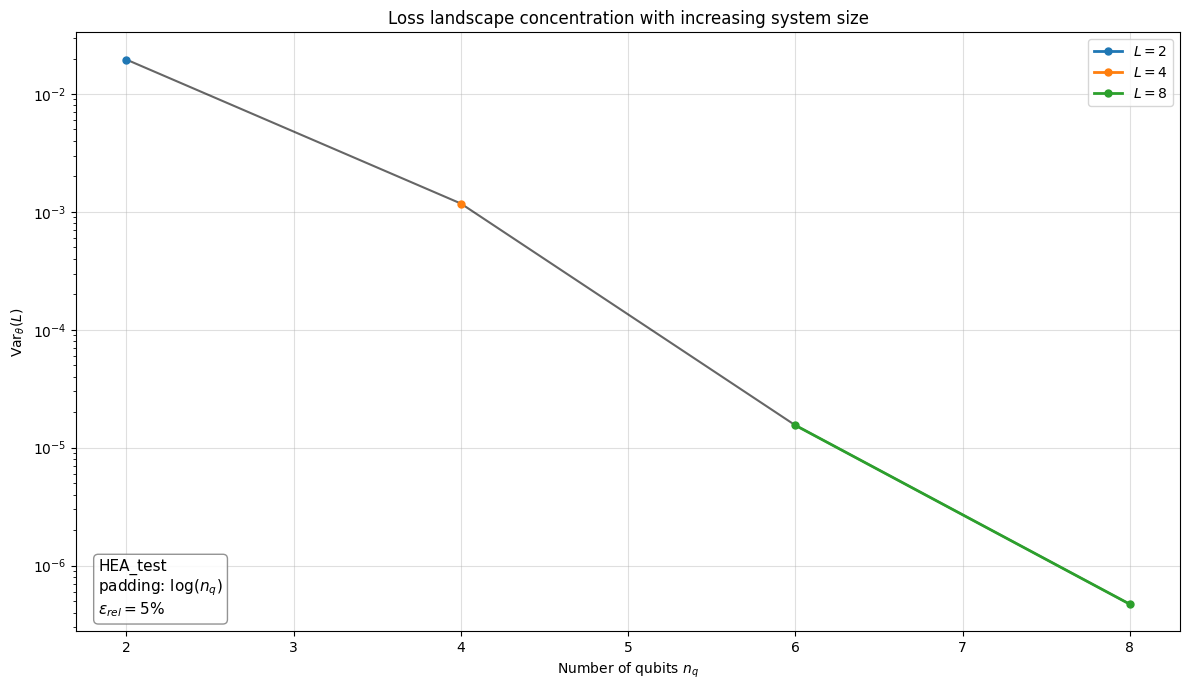

In [22]:
result2 = bp.barren_plateaus_analysis(
    experiment=experiment2,
    cost_function_builder=circuit_mse_loss_builder,
    generate_params=generate_params_hea,
    generate_circuits=build_hea_ansatz,
    sampling=sampling,
    execution=execution,
)

--------------------
Number of qubits: 2
Number of layers: 2
Pauli string: IZ


[Adaptive sampling] N = 900 | relative error = 5.96%
[Adaptive sampling] Adding 637 samples (N: 900 -> 1537)


[Adaptive sampling] N = 1537 | relative error = 4.16%
[Adaptive sampling] Target reached with N_samples = 1537 (relative error target reached)
var = 0.019938798625555313
--------------------
Number of qubits: 4
Number of layers: 2
Pauli string: IZIZ


[Adaptive sampling] N = 900 | relative error = 9.16%
[Adaptive sampling] Adding 2724 samples (N: 900 -> 3624)


[Adaptive sampling] N = 3624 | relative error = 4.37%
[Adaptive sampling] Target reached with N_samples = 3624 (relative error target reached)
var = 0.005701945447274868
--------------------
Number of qubits: 6
Number of layers: 2
Pauli string: IZZIZZ


...

[Adaptive sampling] N = 4967 | relative error = 4.06%
[Adaptive sampling] Target reached with N_samples = 4967 (relative error target reached)
var = 0.0006665355475680662
--------------------
Number of qubits: 6
Number of layers: 8
Pauli string: IZZIZZ


[Adaptive sampling] N = 900 | relative error = 8.13%
[Adaptive sampling] Adding 1959 samples (N: 900 -> 2859)


[Adaptive sampling] N = 2859 | relative error = 4.08%
[Adaptive sampling] Target reached with N_samples = 2859 (relative error target reached)
var = 1.5499255910080055e-05
--------------------
Number of qubits: 8
Number of layers: 8
Pauli string: IZZZZZZZ


[Adaptive sampling] N = 900 | relative error = 8.26%
[Adaptive sampling] Adding 2048 samples (N: 900 -> 2948)


[Adaptive sampling] N = 2948 | relative error = 4.96%
[Adaptive sampling] Target reached with N_samples = 2948 (relative error target reached)
var = 5.006067259950864e-07


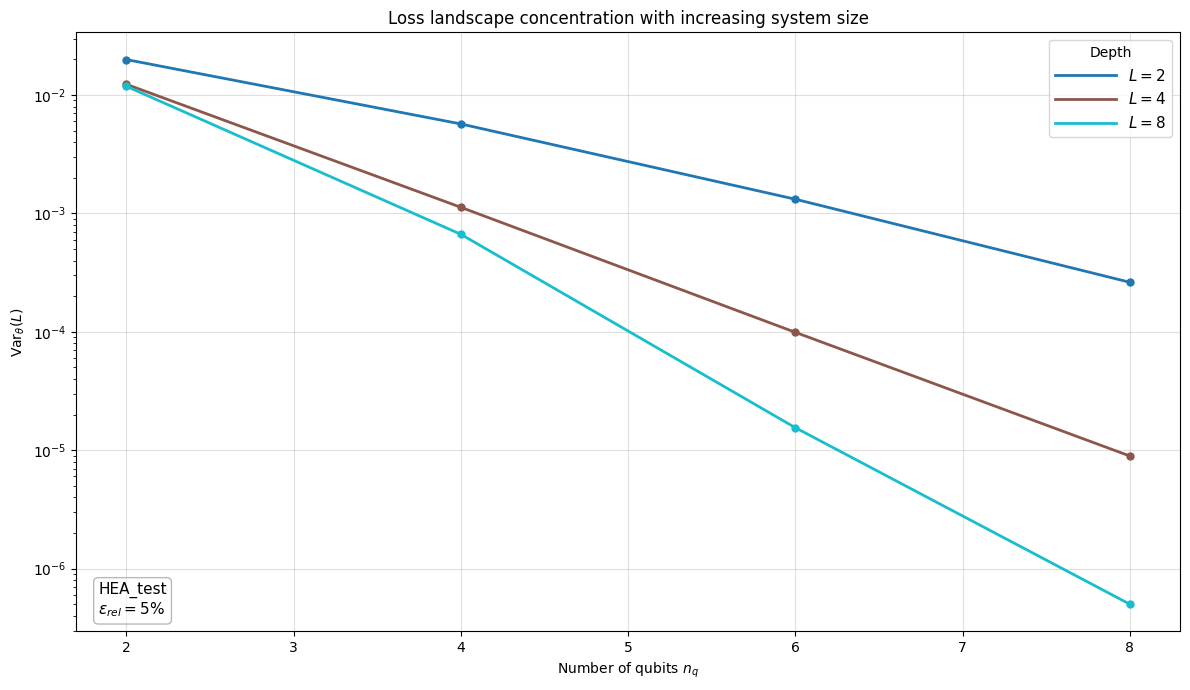

In [23]:
result3 = bp.barren_plateaus_analysis(
    experiment=experiment3,
    cost_function_builder=circuit_mse_loss_builder,
    generate_params=generate_params_hea,
    generate_circuits=build_hea_ansatz,
    sampling=sampling,
    execution=execution,
)